## Problem statement
Given a path observed from a stochastic process modeled by
$$

dS_t = \mu S_t dt + \sigma S_t dB_t

$$
We aim to estimate the parameters such as $\mu$ and $\sigma$. Now let's do some math, suppose we observed $S_{t_{i}}$, we need to find $\hat{\mu}$ and $\hat{\sigma}$. We know that
$$
\ln S_{t_{i + 1}} - \ln S_{t} = \left( \mu-\frac{\sigma^2}{2} \right)\Delta _{t} + \sigma B_{\Delta_{t}}
$$
where $\Delta_{t} = t_{i + 1} - t_{i}$ and $B_{\Delta_{t}} \sim N(0, \Delta_{t})$. 
## Solution
Suppose $\Delta_{t}$ is the same for all $i$, there are certain things that we can do here. The easiest thing we can do is to take the mean of the observed value, that would give $\mu - \frac{\sigma^2}{2}$ easily. Then we estimate the variance. So the parameter estimation here is just robust statistic. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:

def generate_gbm_paths(S0, mu, sigma, T, N, M, mesh_size=1e-3):
    dt = mesh_size
    num_steps = int(T / dt)
    paths = np.zeros((M, num_steps + 1))
    paths[:, 0] = S0
    for i in range(1, num_steps + 1):
        Z = np.random.standard_normal(M)
        paths[:, i] = paths[:, i - 1] + paths[:, i - 1] * mu * dt + paths[:, i - 1] * sigma * np.sqrt(dt) * Z
    # Only return exactly N time steps spaced out evenly over the interval [0, T]
    step_indices = np.linspace(0, num_steps, N + 1, dtype=int)
    return paths[:, step_indices]

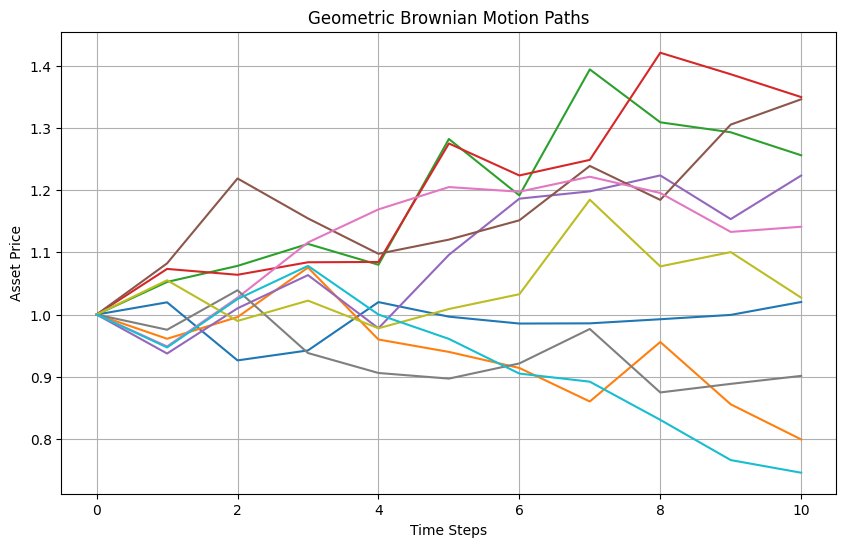

In [3]:
paths = generate_gbm_paths(S0=1, mu=0.1, sigma=0.2, T=1, N=10, M=10)
# Plot the paths
plt.figure(figsize=(10, 6))
for i in range(paths.shape[0]):
    plt.plot(paths[i], label=f'Path {i+1}')
plt.title('Geometric Brownian Motion Paths')
plt.xlabel('Time Steps')
plt.ylabel('Asset Price')
plt.grid()
plt.show()

In [4]:
def path_wise_gbm_parameter_estimation(paths, T):
    N = paths.shape[1] - 1  # Number of time steps
    dt = T / N
    mu_estimates = []
    sigma_estimates = []
    
    for path in paths:
        log_returns = np.diff(np.log(path))
        sampled_variance = np.var(log_returns, ddof=1)
        mu_hat = np.mean(log_returns) / dt + (sampled_variance / (2 * dt))
        sigma_hat = np.sqrt(sampled_variance / dt)
        mu_estimates.append(mu_hat)
        sigma_estimates.append(sigma_hat)
    
    return np.array(mu_estimates), np.array(sigma_estimates)

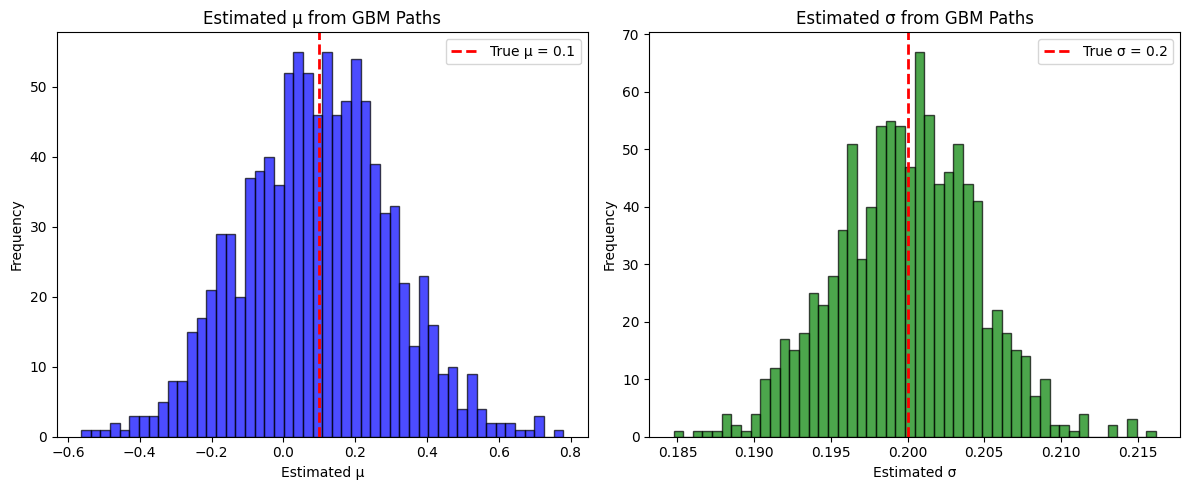

In [5]:
true_mu = 0.1
true_sigma = 0.2
paths = generate_gbm_paths(S0=1, mu=true_mu, sigma=true_sigma, T=1, N=1000, M=1000, mesh_size=1e-4)
estimated_mu, estimated_sigma = path_wise_gbm_parameter_estimation(paths, T=1)
# Plot the histogram of estimated parameters and mark the true values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(estimated_mu, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(true_mu, color='red', linestyle='dashed', linewidth=2, label=f'True μ = {true_mu}')
plt.title('Estimated μ from GBM Paths')
plt.xlabel('Estimated μ')
plt.ylabel('Frequency')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(estimated_sigma, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.axvline(true_sigma, color='red', linestyle='dashed', linewidth=2, label=f'True σ = {true_sigma}')
plt.title('Estimated σ from GBM Paths')
plt.xlabel('Estimated σ')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

So far we can say that the estimator is unbiased. We can run the block above multiple times to realize that if we rely on a single path to estimate the parameters, the error is large, in other words, the variance is big. I wonder what's the distribution of the estimated parameters?

Let us define $X = \ln S_{t_{i + 1}} - \ln {S_{t}}$, then
$$
\begin{align}
\hat{\mu}_{X} = \sum_{i} \frac{X_{i}}{N} \quad \hat{\sigma}^2_{X} = \sum_{i} \frac{(X_{i} - \hat{\mu}_{X})^2}{N - 1} \\
\mu = \frac{\mu_{X}}{\Delta_{t}} + \frac{\sigma^2_{X}}{2\Delta_{t}} \quad \sigma = \frac{\sigma_{X}}{\sqrt{ \Delta_{t} }} \\ \\
\hat{\mu} = \frac{\hat{\mu}_{X}  + \hat{\sigma}_{X}^2 / 2}{\Delta_{t}} \quad \hat{\sigma} = \frac{\hat{\sigma}_{X}}{\sqrt{ \Delta_{t} }}
\end{align}
$$
And for the variance, the classical statistic result gives
$$
\frac{(N- 1)\hat{\sigma}_{X}^2}{\sigma^2_{X}} \sim \chi^2_{N-1} \Rightarrow \hat{\sigma}_{X}^2 \sim \frac{\sigma^2_{X}}{N - 1} \chi^2_{N - 1} \Rightarrow \hat{\sigma}^2 \sim \frac{\sigma^2}{N - 1} \chi^2_{N - 1} 
$$
Well, Central Limit Theorem tells us that, as $N\to \infty$
$$
\sqrt{ N }(\hat{\mu}_{X} - \mu_{X}) \sim N(0, \sigma_{X}^2)
$$
Let $\Phi \sim N(0, 1)$, we can asymptotically write
$$
\begin{align}
\Delta_{t}(\hat{\mu} - \mu) &= \hat{\mu}_{X}-\mu_{X}  + \frac{\hat{\sigma}_{X}^2}{2} - \frac{\sigma_{X}^2}{2} \\
&= \frac{\sigma_{X}}{\sqrt{ N }} \Phi + \frac{\sigma^2_{X}}{2}\left( \frac{\chi^2_{N-1}}{N-1} - 1 \right) \\
\Rightarrow (\hat{\mu} - \mu) &= \frac{\sigma}{\sqrt{ \Delta_{t} N }} \Phi + \frac{\sigma^2}{2}\left( \frac{\chi^2_{N-1}}{(N-1)} - 1 \right) \\
\Rightarrow E[\hat{\mu}-\mu] &= 0 + \frac{\sigma^2}{2}\left( \frac{N-1}{N-1}-1 \right) = 0 \\
\mathrm{Var}[\hat{\mu}] &= \frac{\sigma^2}{T} + \left( \frac{\sigma^2}{2} \right)^2 \frac{2}{N - 1} \\
&= \frac{\sigma^2}{T} + \frac{\sigma^4}{2(N - 1)}
\end{align}
$$
Note that we have just glossed over the fact that the two components are independent, thanks to Basu's theorem. Now we can finally explain why the distribution of doesn't change that much when we increase or decrease $N$, that is because we still have the term $\frac{\sigma^2}{T}$ that DOESN'T SHRINK AT ALL. Well interesting. This is not as trivial as I thought. So good luck estimating drift term from the path. You need to extend the range of the observation, not chopping the time interval into smaller steps. For the volatility,
$$
\begin{align}
\hat{\sigma} - \sigma &= \sigma\left( \sqrt{ \frac{\chi^2_{N-1}}{N-1} } - 1 \right) \\
E[\hat{\sigma} - \sigma] &= \sigma\left( E\left[\sqrt{ \frac{\chi^2_{N-1}}{N-1} }\right] - 1 \right) < \sigma\left( \sqrt{ E\left[ \frac{\chi^2_{N-1}}{N-1} \right] } - 1 \right) = 0
\end{align}
$$
By using the Jensen identity, we can see that the estimated volatility is biased. Well, but how biased? To do that, we need to find $E[\sqrt{ W }]$ for $W \sim \chi^2_{k}$ If you are strong enough in calculus (which I'm not), you can derive
$$
\begin{align}
E[\sqrt{ W }] &= \int_{0}^{\infty} \sqrt{ w } f_{W}(w) \, dw =  \frac{1}{2^{k/2}\Gamma(k / 2)} \int_{0}^{\infty} w^{(k + 1) / 2 - 1} e^{-w / 2} \, dw \\
&= \frac{2^{(k + 1) / 2 - 1}}{2^{k/2}\Gamma(k / 2)} \cdot 2 \cdot\int_{0}^{\infty} u^{(k + 1) / 2 - 1} e^{-u} \, du = \sqrt{ 2 } \frac{\Gamma((k + 1) / 2)}{\Gamma(k / 2)} \\
\end{align}
$$
From that, we can find
$$
E[\hat{\sigma} - \sigma] = \sigma \left(\frac{\sqrt{ 2 }}{\sqrt{ (N - 1) }} \frac{\Gamma(N / 2)}{\Gamma((N - 1) / 2)} - 1\right)
$$
or equivalently,
$$
E[\hat{\sigma}] = \sigma \frac{\sqrt{ 2 }}{\sqrt{ (N - 1) }} \frac{\Gamma(N / 2)}{\Gamma((N - 1) / 2)} = \sigma c_{4}(N)
$$
The variance is
$$
\begin{align}
\mathrm{Var}[\hat{\sigma}] &= \frac{\sigma^2}{N - 1}\mathrm{Var}[\sqrt{ W }] = \frac{\sigma^2}{N - 1}(E[\sqrt{ W } ^ 2] - E[\sqrt{ W }]^2) = \frac{\sigma^2}{N-1}\left(N - 1 - 2 \frac{\Gamma(N / 2)^2}{\Gamma((N - 1) / 2)^2}\right) \\
&= \sigma^2(1 - c_{4}^2(N))
\end{align}
$$

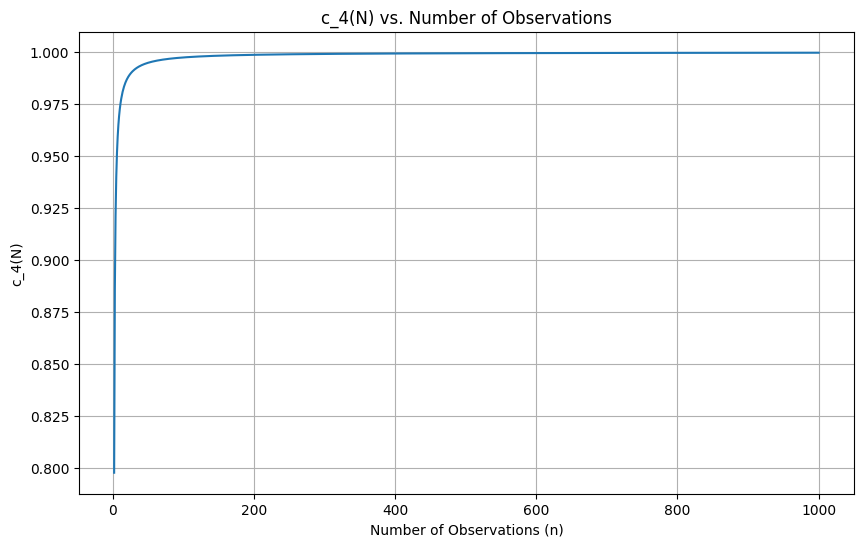

In [6]:
# Plot the graph of c_4(N): sqrt(2/(n - 1)) * gamma(n/2) / gamma((n - 1)/2) versus n
n_values = np.arange(2, 1001)
gamma_ratio = np.sqrt(2 / (n_values - 1)) * np.exp(
    np.array([math.lgamma(n / 2) - math.lgamma((n - 1) / 2)  for n in n_values])
)
plt.figure(figsize=(10, 6))
plt.plot(n_values, gamma_ratio, label=r'$c_4(N) = \sqrt{\frac{2}{n - 1}} \cdot \frac{\Gamma(n/2)}{\Gamma((n - 1)/2)} - 1$')
plt.title('c_4(N) vs. Number of Observations')
plt.xlabel('Number of Observations (n)')
plt.ylabel('c_4(N)')
plt.grid()

Variance of estimated μ: 0.04206597037508602
Variance of estimated σ: 0.004506719477974685
Theoretical variance of estimated μ: 0.04020000000000001
Theoretical variance of estimated σ: 0.004657082647114789
Mean relative error of μ: 0.04641717350960229
Mean relative error of σ: 0.03228698748416207


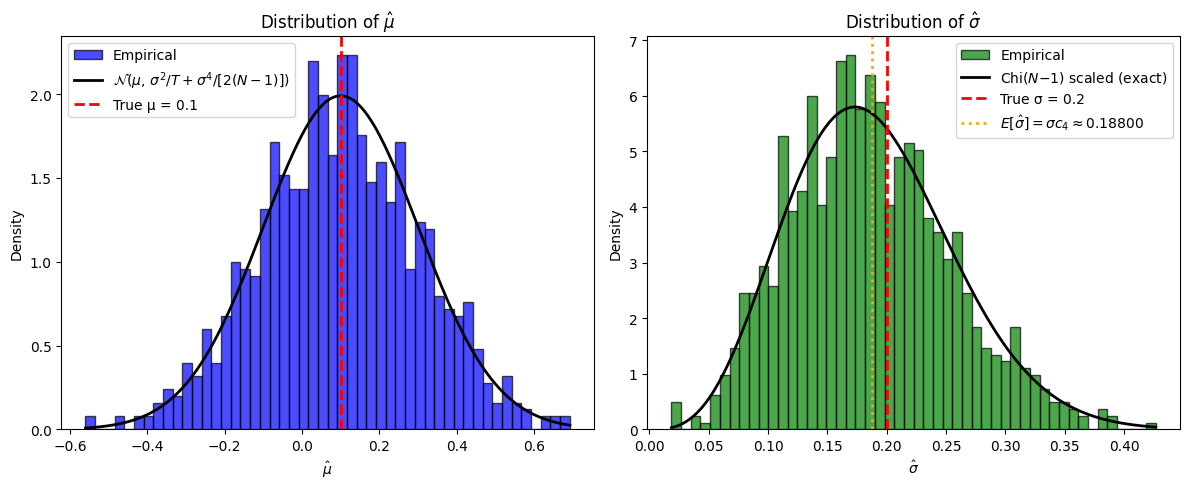

In [7]:
## Verifying the computation above
true_mu = 0.1
true_sigma = 0.2
n_observations = 5
T = 1
paths = generate_gbm_paths(S0=1, mu=true_mu, sigma=true_sigma, T=T, N=n_observations, M=1000, mesh_size=1e-4)
estimated_mu, estimated_sigma = path_wise_gbm_parameter_estimation(paths, T=T)

var_estimated_mu = np.var(estimated_mu)
var_estimated_sigma = np.var(estimated_sigma)
print(f"Variance of estimated μ: {var_estimated_mu}")
print(f"Variance of estimated σ: {var_estimated_sigma}")
theoretical_var_mu = (true_sigma**2)/T + true_sigma**4/(2 * (n_observations - 1))
c4_coefficient = np.sqrt(2 / (n_observations - 1)) * np.exp(
    math.lgamma(n_observations / 2) - math.lgamma((n_observations - 1) / 2)
)
theoretical_var_sigma = (true_sigma**2) * (1 - c4_coefficient**2)
print(f"Theoretical variance of estimated μ: {theoretical_var_mu}")
print(f"Theoretical variance of estimated σ: {theoretical_var_sigma}")

# Calculate the rate of error versus the observed value
error_mu = np.abs(var_estimated_mu - theoretical_var_mu) / theoretical_var_mu
error_sigma = np.abs(var_estimated_sigma - theoretical_var_sigma) / theoretical_var_sigma
print(f"Mean relative error of μ: {np.mean(error_mu)}"
      f"\nMean relative error of σ: {np.mean(error_sigma)}")

from scipy.stats import chi, norm

plt.figure(figsize=(12, 5))

# --- mu_hat ---
plt.subplot(1, 2, 1)
plt.hist(estimated_mu, bins=50, density=True, alpha=0.7,
         color='blue', edgecolor='black', label='Empirical')

var_mu_theo = true_sigma**2 / T + true_sigma**4 / (2 * (n_observations - 1))
x_mu = np.linspace(estimated_mu.min(), estimated_mu.max(), 500)
pdf_mu = norm.pdf(x_mu, loc=true_mu, scale=np.sqrt(var_mu_theo))
plt.plot(x_mu, pdf_mu, 'k-', lw=2,
         label=r'$\mathcal{N}(\mu,\,\sigma^2/T + \sigma^4/[2(N-1)])$')

plt.axvline(true_mu, color='red', linestyle='dashed', lw=2, label=f'True μ = {true_mu}')
plt.title(r'Distribution of $\hat\mu$')
plt.xlabel(r'$\hat\mu$'); plt.ylabel('Density'); plt.legend()

# --- sigma_hat ---
plt.subplot(1, 2, 2)
plt.hist(estimated_sigma, bins=50, density=True, alpha=0.7,
         color='green', edgecolor='black', label='Empirical')

# Exact: sigma_hat = (sigma / sqrt(N-1)) * sqrt(chi^2_{N-1}) = scaled Chi(df=N-1)
x_sigma = np.linspace(estimated_sigma.min(), estimated_sigma.max(), 500)
pdf_sigma = chi.pdf(x_sigma, df=n_observations - 1,
                    scale=true_sigma / np.sqrt(n_observations - 1))
plt.plot(x_sigma, pdf_sigma, 'k-', lw=2, label=r'$\mathrm{Chi}(N{-}1)$ scaled (exact)')

# Also mark the biased mean E[sigma_hat] = sigma * c4(N)
c4 = np.sqrt(2 / (n_observations - 1)) * np.exp(
    math.lgamma(n_observations / 2) - math.lgamma((n_observations - 1) / 2)
)
plt.axvline(true_sigma, color='red', linestyle='dashed', lw=2,
            label=f'True σ = {true_sigma}')
plt.axvline(true_sigma * c4, color='orange', linestyle='dotted', lw=2,
            label=fr'$E[\hat\sigma] = \sigma c_4 \approx {true_sigma*c4:.5f}$')

plt.title(r'Distribution of $\hat\sigma$')
plt.xlabel(r'$\hat\sigma$'); plt.ylabel('Density'); plt.legend()

plt.tight_layout()
plt.show()

# Cramér–Rao Efficiency: A Better Lens for Estimator Analysis

From here we have two ways to go:
- Find a better approach for the current problem: Can we have a different estimator other than the mean? Maybe we can have some kind of algorithm / statistic along the way to enhance the result? Maybe something like Kalman Filter? I'm thinking something like this: We have a prior of the parameters and we have a certain amount of tolerance, like I'm sure 80% that my prior is correct (can change along the time) and then we update the prior as we observe data. What's this kind of paradigm called? Bayesian Inference?
- Extend the problem, for example, stochastic volatility / drift

So far we've been analyzing estimators ad hoc — bias here, variance there. The Cramér–Rao framework gives us a unified way to ask *how good* an estimator can possibly be, and whether ours hits that ceiling. Spoiler: with this tool, we'll see why the first direction (estimating $\mu$ via more frequent sampling) is a dead end.

> *In statistics, efficiency is a measure of quality of an estimator… A more efficient estimator needs fewer observations than a less efficient one to achieve the Cramér–Rao bound. An efficient estimator has the smallest possible variance, indicating small deviance from the true value in the $L^2$ sense.*

To get there, we first need the **Fisher information**. The full theory deserves its own treatment; here we'll go through it pragmatically.

## The Score

The score of a parameter $\theta$ is
$$
s(\theta, x) = \frac{\partial}{\partial \theta}\ln f(x; \theta),
$$
where $f(x; \theta)$ is the density of $X$ under parameter $\theta$. Treating $X$ as random, $s(\theta)$ becomes a random variable. The **Fisher information** is its variance:
$$
\mathcal{I}(\theta) = \mathrm{Var}[s(\theta) \mid \theta].
$$

Geometrically, the score points in the steepest-ascent direction of the log-likelihood at $(\theta, x)$. A first key fact: under the true parameter, the expected score vanishes.

$$
\begin{align}
E[s(\theta) \mid \theta] &= \int_{-\infty}^{\infty} \frac{\partial}{\partial \theta}\ln f(x ; \theta) \cdot f(x;\theta) \, dx  \\
&= \int_{-\infty}^{\infty} \frac{1}{f(x;\theta)} \frac{\partial f(x;\theta)}{\partial \theta} \cdot f(x;\theta) \, dx  \\
&= \frac{\partial}{\partial \theta} \int_{-\infty}^{\infty} f(x;\theta) \, dx = \frac{\partial}{\partial \theta} 1 = 0.
\end{align}
$$

**Why this matters intuitively.** Imagine running a stochastic gradient ascent to find the true parameter. Each sample $x$ gives you a direction vector — the score evaluated at $(\theta, x)$. The identity above says: if $\theta$ is already the true parameter, the *average* update is zero. You're at the optimum on average.

So why care about the *variance* of the score at the true $\theta$? Because variance measures how much information each sample carries. A high-variance score means individual samples disagree strongly about which way to move — paradoxically, that's *good*: each sample is informative. A low-variance score means every sample tells you the same thing, which means there's not much new information to gain by sampling more. Higher Fisher information ⇒ each observation is more informative.

## The Second-Derivative Form

There's an equivalent formulation that's often easier to compute:

$$
\begin{align}
\frac{\partial^2 \ln f}{\partial \theta^2} &= \frac{\partial}{\partial \theta}\!\left( \frac{1}{f}\frac{\partial f}{\partial \theta} \right) = -\frac{1}{f^2}\!\left( \frac{\partial f}{\partial \theta} \right)^{\!2} + \frac{1}{f}\frac{\partial^2 f}{\partial \theta^2}.
\end{align}
$$

Integrating against $f$:

$$
\begin{align}
\int \frac{\partial^2 \ln f}{\partial \theta^2}\, f \, dx &= -\int \frac{\left( \partial_\theta f \right)^2}{f}\, dx + \frac{\partial^2}{\partial \theta^2}\int f \, dx \\
&= -\int \left( \frac{\partial \ln f}{\partial \theta} \right)^{\!2} f \, dx.
\end{align}
$$

Combined with $E[s] = 0$ (so $\mathrm{Var}[s] = E[s^2]$):

$$
\boxed{\;\mathcal{I}(\theta) = \mathrm{Var}[s(\theta)] = -E\!\left[ \frac{\partial^2 \ln f}{\partial \theta^2} \right].\;}
$$

**Geometric interpretation.** Plot $\ln f(x; \theta)$ as a function of $\theta$ for various realizations of $X$. The Fisher information at the true $\theta$ tells us how *peaked* this curve is around its maximum, on average. A sharply peaked log-likelihood means the data strongly distinguishes nearby parameter values — high information. A flat one means the data can't tell similar $\theta$ values apart.

## The Cramér–Rao Bound

For any unbiased estimator $\hat\mu(\mathbf{x})$ of $\theta$:
$$
\mathrm{Var}[\hat\mu(\mathbf{x})] \;\geq\; \frac{1}{\mathcal{I}(\theta)}.
$$

**Proof.** Start from the correlation inequality $|\rho(\hat\mu, s)| \leq 1$:
$$
\mathrm{Var}[\hat\mu] \;\geq\; \frac{\mathrm{Cov}(\hat\mu, s)^2}{\mathrm{Var}[s]} = \frac{E[\hat\mu \cdot s]^2}{\mathrm{Var}[s]}.
$$

Now compute the numerator using the same density-derivative trick:
$$
E[\hat\mu(\mathbf{x})\, s(\mathbf{x},\theta)] = \int \hat\mu(\mathbf{x}) \frac{\partial f}{\partial \theta} \, d\mathbf{x} = \frac{\partial}{\partial \theta} \int \hat\mu(\mathbf{x})\, f \, d\mathbf{x} = \frac{\partial}{\partial \theta} E[\hat\mu] = \frac{\partial \theta}{\partial \theta} = 1.
$$

Therefore:
$$
\mathrm{Var}[\hat\mu] \;\geq\; \frac{1}{\mathcal{I}(\theta)}. \qquad \blacksquare
$$

## Application 1: The Drift $\mu$

For the GBM log-return $X = (\mu - \sigma^2/2)\Delta_t + \sigma B_{\Delta_t}$:
$$
f(x) = \frac{1}{\sqrt{2\pi\sigma^2\Delta_t}}\exp\!\left\{ -\frac{(x - (\mu - \sigma^2/2)\Delta_t)^2}{2\sigma^2\Delta_t} \right\},
$$
$$
\ln f(x) = -\frac{(x - (\mu - \sigma^2/2)\Delta_t)^2}{2\sigma^2\Delta_t} - \frac{1}{2}\ln(2\pi\sigma^2\Delta_t).
$$

Differentiating in $\mu$:
$$
\frac{\partial \ln f}{\partial \mu} = \frac{x}{\sigma^2} + \frac{\Delta_t}{2} - \frac{\mu \Delta_t}{\sigma^2}, \qquad -\frac{\partial^2 \ln f}{\partial \mu^2} = \frac{\Delta_t}{\sigma^2}.
$$

So $\mathcal{I}(\mu) = \Delta_t / \sigma^2$ per observation. With $N$ iid samples:
$$
\mathcal{I}_N(\mu) = \frac{N\Delta_t}{\sigma^2} = \frac{T}{\sigma^2},
$$
and the Cramér–Rao bound reads
$$
\mathrm{Var}[\hat\mu] \;\geq\; \frac{\sigma^2}{T}.
$$

**Notice what dropped out: $N$ and $\Delta_t$ separately don't matter — only their product $T$ does.** Sampling more frequently at fixed horizon buys nothing for drift estimation. To halve the standard error, you need 4× the calendar time.

Our unbiased MLE for $\mu$ has variance
$$
\mathrm{Var}[\hat\mu] = \frac{\sigma^2}{T} + \frac{\sigma^4}{2(N-1)},
$$
which converges to $\sigma^2/T$ as $N \to \infty$. The estimator is **asymptotically efficient**.

## Application 2: The Volatility $\sigma$

The volatility derivation is messier because the mean $(\mu - \sigma^2/2)\Delta_t$ also depends on $\sigma$. Setting $Z = x - (\mu - \sigma^2/2)\Delta_t$ so that $\partial Z/\partial \sigma = \sigma\Delta_t$:

$$
\ln f(x) = -\frac{Z^2}{2\sigma^2\Delta_t} - \frac{1}{2}\ln(2\pi\sigma^2\Delta_t).
$$

**First derivative:**
$$
\begin{align}
\frac{\partial \ln f}{\partial \sigma} &= -\frac{1}{\sigma} - \frac{\partial}{\partial \sigma}\!\left( \frac{Z^2}{2\sigma^2\Delta_t} \right) \\
&= -\frac{1}{\sigma} - \frac{Z}{\sigma} + \frac{Z^2}{\sigma^3\Delta_t}.
\end{align}
$$

The middle $-Z/\sigma$ term is what's "extra" compared to a textbook normal — it comes purely from $\sigma$ leaking into the mean.

**Second derivative:**
$$
\begin{align}
\frac{\partial^2 \ln f}{\partial \sigma^2} &= \frac{1}{\sigma^2} - \Delta_t + \frac{3Z}{\sigma^2} - \frac{3Z^2}{\sigma^4\Delta_t}.
\end{align}
$$

**Fisher information.** Using $E[Z] = 0$ and $E[Z^2] = \sigma^2\Delta_t$:
$$
\mathcal{I}(\sigma) = -E\!\left[ \frac{\partial^2 \ln f}{\partial \sigma^2} \right] = -\frac{1}{\sigma^2} + \Delta_t + \frac{3\sigma^2\Delta_t}{\sigma^4\Delta_t} = \frac{2}{\sigma^2} + \Delta_t.
$$

For typical $\Delta_t$ the second term is negligible, so per observation $\mathcal{I}(\sigma) \approx 2/\sigma^2$. With $N$ samples the Cramér–Rao bound becomes
$$
\mathrm{Var}[\hat\sigma] \;\geq\; \frac{\sigma^2}{2N}.
$$

**Compare with what we computed before:**
$$
\mathrm{Var}[\hat\sigma] = \sigma^2(1 - c_4^2(N)) \approx \frac{\sigma^2}{2N}.
$$

The biased estimator $\hat\sigma$ is also asymptotically efficient (the bias $c_4 - 1$ vanishes faster than the standard error, so applying CRB asymptotically is justified).

## Takeaway

Both estimators saturate the Cramér–Rao bound asymptotically — they're as good as it gets. But the *bounds themselves* tell different stories:

| Parameter | CRB | What controls precision |
|-----------|---------------------|----------------------------|
| $\mu$     | $\sigma^2 / T$      | Calendar time only         |
| $\sigma$  | $\sigma^2 / (2N)$   | Number of observations $N$ |

So sampling more frequently at fixed $T$ does nothing for $\mu$ but crushes the error on $\sigma$. **The first direction — estimating drift via finer sampling — is fundamentally not worth pursuing.** This isn't a flaw in our estimator; it's a flaw in the question. No unbiased estimator can do better.